In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
control = pd.read_csv(
    "control_group.csv",
    sep=';'
)

test = pd.read_csv(
    "test_group.csv",
    sep=';'
)

In [3]:
print(control.shape)

print(test.shape)

(30, 10)
(30, 10)


In [4]:
df = pd.concat(
    [control,test],
    ignore_index=True
)

df.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Check Missing Values**

In [5]:
df.isnull().sum()

,0
Campaign Name,0
Date,0
Spend [USD],0
# of Impressions,1
Reach,1
# of Website Clicks,1
# of Searches,1
# of View Content,1
# of Add to Cart,1
# of Purchase,1


# **Fill Missing Values**

In [6]:
df = df.fillna(
    df.mean(
        numeric_only=True
    )
)

# **Total Purchases by Campaign**

In [7]:
df.groupby(

'Campaign Name'

)['# of Purchase'].sum()

,# of Purchase
Campaign Name,
Control Campaign,15683.0
Test Campaign,15637.0


# **Total Website Clicks**

In [8]:
df.groupby(

'Campaign Name'

)['# of Website Clicks'].sum()

,# of Website Clicks
Campaign Name,
Control Campaign,159985.59322
Test Campaign,180970.00000


# **Conversion Rate**

In [10]:
df['Conversion Rate'] = (

df['# of Purchase']

/

df['# of Website Clicks']

)*100

In [11]:
df.groupby(

'Campaign Name'

)['Conversion Rate'].mean()

,Conversion Rate
Campaign Name,
Control Campaign,11.400828
Test Campaign,9.231182


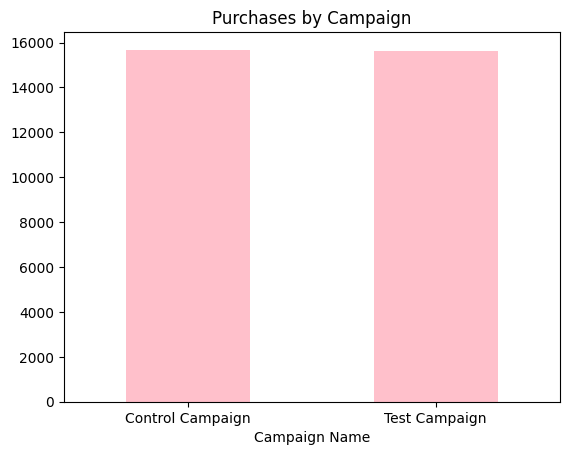

In [15]:
purchase = df.groupby(

'Campaign Name'

)['# of Purchase'].sum()

purchase.plot(
kind='bar',
color="pink"
)

plt.title(
'Purchases by Campaign'
)

plt.xticks(rotation=0)
plt.show()

# **Cost per Purchase**
Cost per Purchase = Spend / Purchases

In [16]:
df['Cost per Purchase'] = (
    df['Spend [USD]']
    /
    df['# of Purchase']
)

**Average Cost per Purchase by Campaign**

In [17]:
cpp = df.groupby(
    'Campaign Name'
)['Cost per Purchase'].mean()

print(cpp)

Campaign Name
Control Campaign    5.001105
Test Campaign       5.899589
Name: Cost per Purchase, dtype: float64


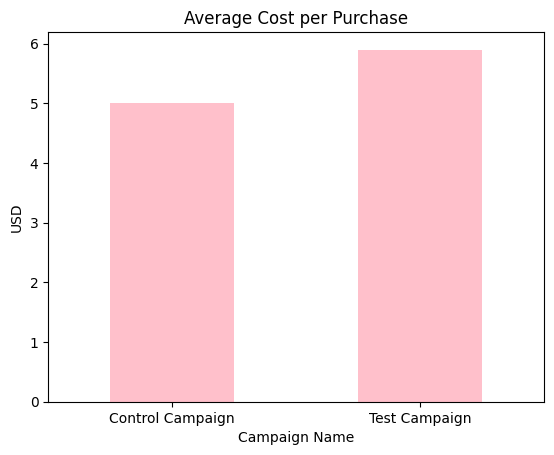

In [19]:
cpp.plot(
    kind='bar',
    color='pink'
)

plt.title("Average Cost per Purchase")
plt.ylabel("USD")
plt.xticks(rotation=0)

plt.show()

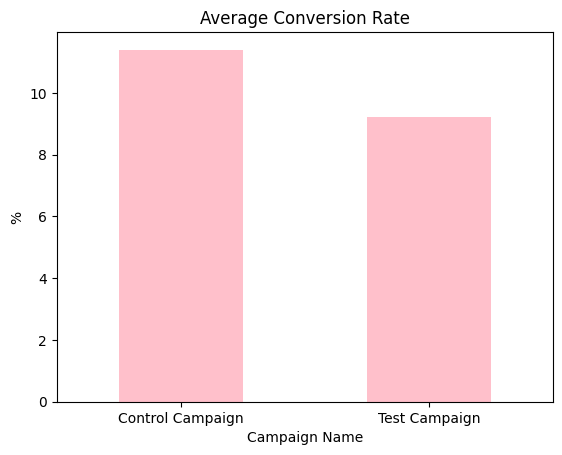

In [21]:
df['Conversion Rate'] = (
    df['# of Purchase']
    /
    df['# of Website Clicks']
) * 100

conversion = df.groupby(
    'Campaign Name'
)['Conversion Rate'].mean()

conversion.plot(kind='bar', color='pink')

plt.title("Average Conversion Rate")
plt.ylabel("%")
plt.xticks(rotation=0)

plt.show()

# **Conclusion**

This project used Python to analyze and compare the performance of Control and Test marketing campaigns through A/B testing techniques. Key performance indicators such as purchases, conversion rate, and cost per purchase were evaluated to determine the effectiveness of each campaign.

The analysis showed that both campaigns generated a similar number of purchases. However, the Control Campaign achieved a lower average cost per purchase, making it more cost-efficient than the Test Campaign. While the Test Campaign performed competitively, the Control Campaign provided better overall marketing efficiency and stronger business value.

These findings demonstrate how data analysis and A/B testing can support evidence-based decision-making, helping businesses optimize marketing strategies, allocate budgets more effectively, and improve overall campaign performance.
